# Counter Vector

In [1]:
# !pip install scikit-learn -q

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 문장 데이터 Copus
corpus = [
    "Hello World",
    "Hello World World",
    "Hello Hello World",
    "Hello Hello World World"
]

In [4]:
# BoW 계산
bow_vectorizer = CountVectorizer() # 텍스트를 단어 빈도 행렬로 변환하는 도구

# 데이터 변환 ( fit_transform(), toarray() )
## 텍스트를 토큰화하여 개별 단어로 분리
## 각 문서에서 단어의 출현 빈도를 계산
## 희소 행렬 (sparse matrix) 형태로 계산
bow_matrix = bow_vectorizer.fit_transform(corpus)
print("BoW 행렬:\n", bow_matrix.toarray())

# 특성 이름 출력
## 각 행은 하나의 문서를 나타냄
## 각 열은 고유한 단어(특성)를 나타냄
## 행렬의 value는 특정 단어가 등장한 횟수
print("BoW 특성 이름:\n", bow_vectorizer.get_feature_names_out())

BoW 행렬:
 [[1 1]
 [1 2]
 [2 1]
 [2 2]]
BoW 특성 이름:
 ['hello' 'world']


In [5]:
# TF-IDF 계산
## Term Frequency-Inverse Document Frequency 문서에서 단어의 중요도를 계산하는 통계적 방법

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
print("\nTF-IDF 행렬:\n", tfidf_matrix.toarray())
print("TF-IDF 특성 이름:\n", tfidf_vectorizer.get_feature_names_out())


TF-IDF 행렬:
 [[0.70710678 0.70710678]
 [0.4472136  0.89442719]
 [0.89442719 0.4472136 ]
 [0.70710678 0.70710678]]
TF-IDF 특성 이름:
 ['hello' 'world']


## 문서별 분석
위의 TF-IDF 행렬의 값을 해석해 보면,

### 문서 1: “Hello World”
* 0.70710678, 0.70710678
* 두 단어가 각각 한 번씩 등장하여 동일한 가중치를 가짐

### 문서 2: “Hello World World”
* 0.4472136, 0.89442719
* ‘world’가 두 번 등장하여 더 높은 가중치를 가짐

### 문서 3: “Hello Hello World”
* 0.89442719, 0.4472136
* ‘hello’가 두 번 등장하여 더 높은 가중치를 가짐

### 문서 4: “Hello Hello World World”
* 0.70710678, 0.70710678
* 두 단어가 각각 두 번씩 등장하여 다시 동일한 가중치를 가짐

### 계산 원리
* TF: 각 문서에서 단어의 등장 횟수
* IDF: 모든 문서에서 해당 단어가 등장하므로 IDF 값은 동일
* 최종 값은 정규화되어 각 문서 벡터의 길이가 1이 되도록 조정됨

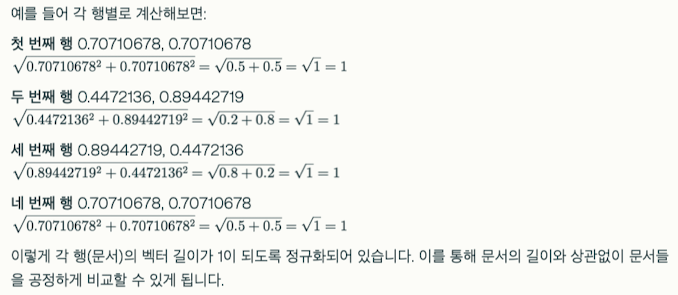